# USPS Fraud Detection 
### with Louvain Community Detection Algorithm on a Graph Network
### Demonstration Notebook

**Note**: This notebook is intended for demonstration purposes, therefore the bulk of the code that
manipulates the data and runs the calculation is abstracted away in separate python modules that
can be found in this repository in the `scripts` folder. 

#### Section 1: Import libraries and data

In [11]:
%matplotlib inline
from scripts.community_scoring import *
from scripts.graph_connector import query_executor
from scripts.neo4j_to_networkx import graph_from_cypher
from scripts.louvain_community_detection import *
from scripts.sample_queries import *
from scripts.community_plots import *
import seaborn as sns

**Query data from Neo4j Graph database**

In [2]:
# query neo4j and read into in-memory graph
data = query_executor(query_all_data)

**Read data into in-memory graph**

In [3]:
graph = graph_from_cypher(data)

Node or Edge import error - Type error - continuing
Node or Edge import error - Attribute error - continuing
Node or Edge import error - Type error - continuing
Node or Edge import error - Attribute error - continuing
total nodes: 22320, total edges: 29590


#### Section 2: Community Detection

In [4]:
communities = louvain_community(graph)

Generating communities...
Community detection elapsed time: 1.0463905334472656
total communities with more than one node: 64


#### Section 3: Results

In [20]:
df_communities_stats = get_communities_stats(graph,communities)
df_sorted = df_communities_stats.sort_values(by='Score', ascending=False).reset_index().drop('index', axis=1)


In [21]:
df_sorted

,Community_id,Density,Fraud_Density,Score,N_Nodes,N_Edges
0,42,0.400000,0.300000,0.346410,5,4
1,15,0.500000,0.166667,0.288675,4,3
2,24,0.500000,0.166667,0.288675,4,3
3,29,0.500000,0.166667,0.288675,4,3
4,39,0.500000,0.166667,0.288675,4,3
...,...,...,...,...,...,...
59,22,0.062500,0.000000,0.000000,32,31
60,30,0.250000,0.000000,0.000000,9,9
61,46,0.080000,0.000000,0.000000,25,24
62,55,0.400000,0.000000,0.000000,5,4


In [19]:
df_percentages = composition_percentages(df_sorted)

In [22]:
node_columns = [col for col in df_sorted.columns if col.endswith('_nodes')]

# Calculate percentages and create new columns
for col in node_columns:
    new_col_name = col + '_perc'
    df_sorted[new_col_name] = df_sorted[col] / df_sorted['N_Nodes']

# Select columns ending with '_edges'
edge_columns = [col for col in df_sorted.columns if col.endswith('_edges')]

# Calculate percentages and create new columns
for col in edge_columns:
    new_col_name = col + '_perc'
    df_sorted[new_col_name] = df_sorted[col] / df_sorted['N_Edges']



In [23]:
df_sorted

,Community_id,Density,Fraud_Density,Score,N_Nodes,N_Edges
0,42,0.400000,0.300000,0.346410,5,4
1,15,0.500000,0.166667,0.288675,4,3
2,24,0.500000,0.166667,0.288675,4,3
3,29,0.500000,0.166667,0.288675,4,3
4,39,0.500000,0.166667,0.288675,4,3
...,...,...,...,...,...,...
59,22,0.062500,0.000000,0.000000,32,31
60,30,0.250000,0.000000,0.000000,9,9
61,46,0.080000,0.000000,0.000000,25,24
62,55,0.400000,0.000000,0.000000,5,4


**Below:** there were 64 communities generated by the algorithm that had a node count greater than 1. After measuring both the density of the community, and the density of the fraud, the geometric mean was calculated for the two scores. The two measurements, and the score, are seen below in the columns `Density`, `Fraud_Density`, and `Score` respectively. The rows below represent every tenth row to show a sorted distribution of scores, from the highest ranking community to the lowest ranking. 

In [24]:
result_sample = df_sorted.iloc[[0, 10, 20, 30, 40, 50, 60]]
result_sample

,Community_id,Density,Fraud_Density,Score,N_Nodes,N_Edges
0,42,0.400000,0.300000,0.346410,5,4
10,47,0.285714,0.095238,0.164957,7,6
20,45,0.013897,0.002752,0.006184,171,202
30,27,0.019417,0.000373,0.002693,104,104
40,31,0.007804,0.000286,0.001494,265,273
50,3,0.001083,0.000265,0.000536,2548,3513
60,30,0.250000,0.000000,0.000000,9,9


#### Node types 

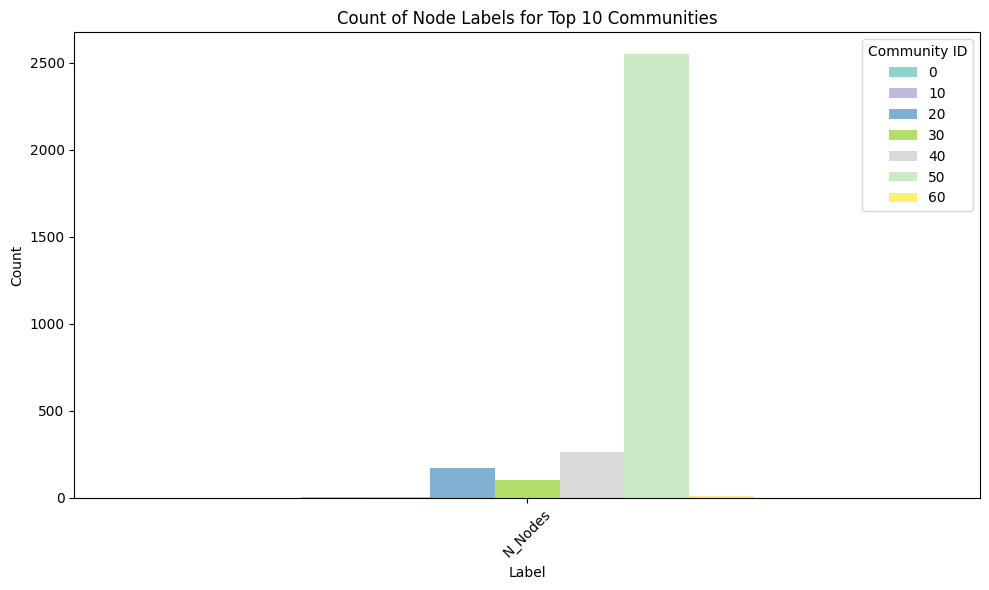

In [25]:
rows = [0, 10, 20, 30, 40, 50, 60]
# Select percentage columns and first 10 rows (sorted by score)
df_to_plot = df_sorted.iloc[rows, df_sorted.columns.str.endswith('_Nodes')]

# Transpose DataFrame for plotting
df_to_plot = df_to_plot.transpose()

# Create bar plot
df_to_plot.plot(kind='bar', figsize=(10, 6), colormap="Set3")
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Count of Node Labels for Top 10 Communities')
plt.xticks(rotation=45)
plt.legend(title='Community ID')
plt.tight_layout()
plt.show()


In [9]:
# Create bar plot
df_to_plot.plot(kind='bar', x='Community_id', y='N_Nodes', figsize=(10, 6), colormap="Set3")
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Count of Node Labels for Top 10 Communities')
plt.xticks(rotation=45)
plt.legend(title='Community ID')
plt.tight_layout()
plt.show()

KeyError: 'Community_id'